In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

In [5]:
df = pd.read_excel("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/" \
"STOXX600_as_of_2025_03_13.xlsx")

In [6]:
df

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
0,Brenntag SE,BNR-DE,BNR-DE,19429.300000,16815.100000,NaN,46.73,G,Brenntag Societas Europaea1.pdf
1,Grafton Group Plc,GFTU-GB,GFTU-GB,2697.420700,2666.632525,NaN,47.52,G,Grafton Group Plc1.pdf
2,LANXESS AG,LXS-DE,LXS-DE,8088.000000,6714.000000,NaN,20.59,C,LANXESS AG1.pdf
3,Banco de Sabadell SA,SAB-ES,SAB-ES,6927.920000,10467.899000,11656.548000,64.19,K,Banco de Sabadell SA1.pdf
4,freenet AG,FNTN-DE,FNTN-DE,2556.714000,2627.300000,NaN,61.20,J,freenet AG1.pdf
...,...,...,...,...,...,...,...,...,...
595,Syensqo SA/NV,SYENS-BE,SYENS-BE,7890.000000,6834.000000,6563.000000,72.11,M,NaN
596,Galderma Group AG,GALD-CH,GALD-CH,3577.917927,3775.451846,4076.950861,21.20,C,NaN
597,"Puig Brands, S.A. Class B",PUIG-ES,PUIG-ES,3619.603000,4304.067000,4789.779000,20.42,C,NaN
598,CVC Capital Partners plc,CVC-NL,CVC-NL,1054.827000,1153.785000,NaN,66.30,K,NaN


In [7]:
df["NACE"]

0      46.73
1      47.52
2      20.59
3      64.19
4      61.20
       ...  
595    72.11
596    21.20
597    20.42
598    66.30
599    60.20
Name: NACE, Length: 600, dtype: float64

<BarContainer object of 171 artists>

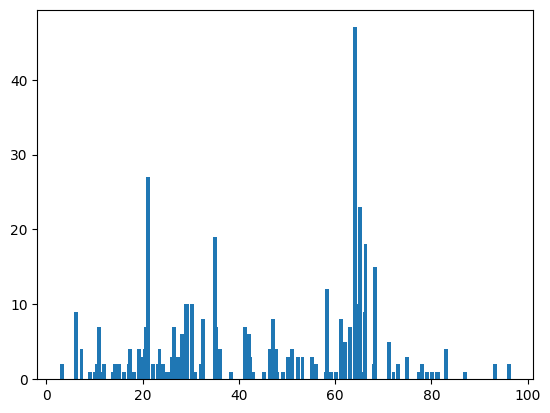

In [8]:
plt.bar(df.groupby("NACE").count().index, df.groupby("NACE").count()["Name"])

In [9]:
df[df["NACE_letter"] == "C"].groupby("NACE").count().index

Index([10.13,  10.2, 10.51, 10.71, 10.72, 10.82, 10.83, 10.89, 11.01, 11.05,
       11.07,  12.0, 13.91, 13.99, 14.13, 14.19, 15.12,  15.2, 16.21, 17.11,
       17.12, 17.22, 17.29,  18.2,  19.2, 20.11, 20.13, 20.14, 20.15, 20.16,
       20.17,  20.3, 20.41, 20.42, 20.59,  21.1,  21.2, 22.11, 22.22, 23.14,
       23.31, 23.51, 23.99,  24.1,  24.2, 24.31, 24.42, 24.44, 24.45,  25.3,
        25.5, 25.72, 25.93, 25.94, 25.99, 26.11,  26.2,  26.3, 26.51, 26.52,
        26.6, 27.11, 27.12,  27.2, 27.32, 27.33,  27.4, 27.51,  27.9, 28.11,
       28.12, 28.13, 28.15, 28.22, 28.25, 28.29,  28.3, 28.92, 28.93, 28.95,
       28.99,  29.2, 29.31,  30.2,  30.3,  30.4, 30.92, 32.12,  32.4,  32.5],
      dtype='float64', name='NACE')

In [10]:
df["NACE_lvl_2"] = df["NACE"].apply(int)

<BarContainer object of 22 artists>

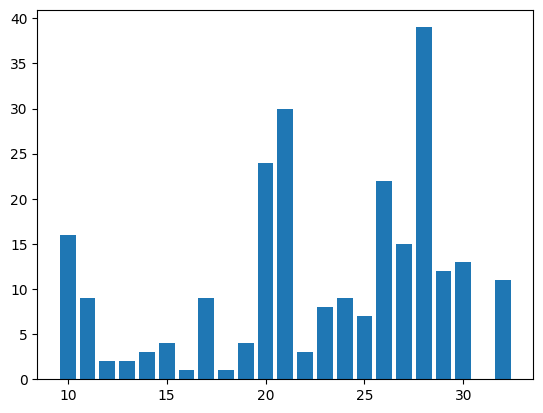

In [11]:
plt.bar(df[df["NACE_letter"] == "C"].groupby("NACE_lvl_2").count().index, df[df["NACE_letter"] == "C"].groupby("NACE_lvl_2").count()["Name"])

<BarContainer object of 17 artists>

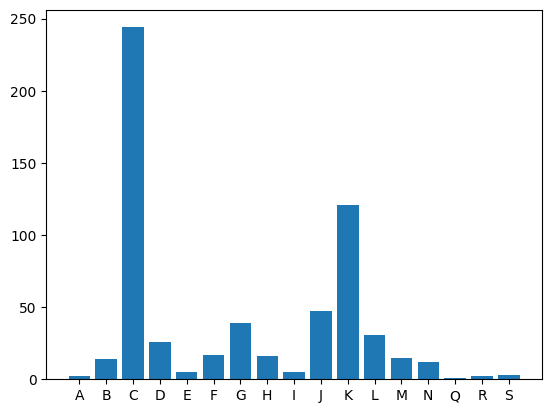

In [12]:
plt.bar(df.groupby("NACE_letter").count().index, df.groupby("NACE_letter").count()["Name"])

In [15]:
pdf_path = "../data/PDF_stoxx600"

In [20]:
pdfs = glob.glob(pdf_path + "/*.pdf")
pdfs = [os.path.basename(pdf) for pdf in pdfs]
pdfs

['Deutsche Lufthansa AG1.pdf',
 'Hermes International SCA2.pdf',
 'RWE AG1.pdf',
 'Nordea Bank Abp1.pdf',
 'Knorr-Bremse AG1.pdf',
 'Rolls-Royce Holdings plc1.pdf',
 'BAE Systems plc1.pdf',
 'SCOR SE2.pdf',
 'Danone SA1.pdf',
 'Terna S.p.A.3.pdf',
 'Swissquote Group Holding Ltd.1.pdf',
 'Acciona SA2.pdf',
 'Baloise-Holding AG2.pdf',
 'Lotus Bakeries NV1.pdf',
 'Kemira Oyj1.pdf',
 'Sartorius Stedim Biotech SA1.pdf',
 'Kering SA1.pdf',
 'Merck KGaA2.pdf',
 'Plus500 Ltd.1.pdf',
 'Universal Music Group N.V.1.pdf',
 'LEG Immobilien SE1.pdf',
 'Wienerberger AG2.pdf',
 'IMI plc1.pdf',
 'Porsche AG1.pdf',
 'Nokia Oyj2.pdf',
 'ConvaTec Group Plc1.pdf',
 'Vidrala SA3.pdf',
 'Nordnet AB1.pdf',
 'Umicore SA1.pdf',
 'Signify NV3.pdf',
 'Associated British Foods plc1.pdf',
 'ANDRITZ AG1.pdf',
 'Azelis Group N.V.1.pdf',
 'Zurich Insurance Group Ltd2.pdf',
 'PUMA SE1.pdf',
 'Ashtead Group plc1.pdf',
 'InterContinental Hotels Group PLC1.pdf',
 'Aalberts N.V.1.pdf',
 'Euronext NV1.pdf',
 'Fresenius SE &

In [24]:
df["pdf_available"] = df["Report"].apply(lambda x: x in pdfs)
df_available = df[df["pdf_available"]]

<BarContainer object of 17 artists>

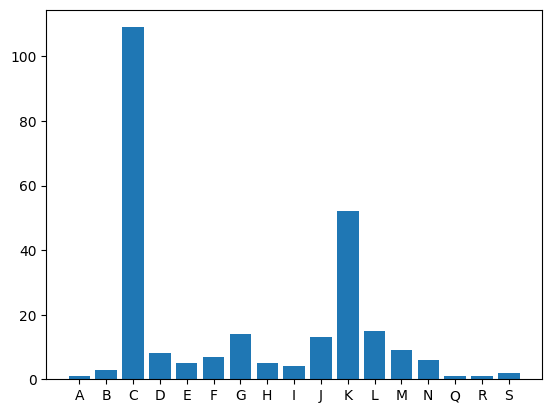

In [25]:
plt.bar(df_available.groupby("NACE_letter").count().index, df_available.groupby("NACE_letter").count()["Name"])

In [28]:
df_available.groupby("NACE_letter").count()["Name"]

NACE_letter
A      1
B      3
C    109
D      8
E      5
F      7
G     14
H      5
I      4
J     13
K     52
L     15
M      9
N      6
Q      1
R      1
S      2
Name: Name, dtype: int64

In [32]:
df_available.sort_values("NACE_letter")

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,NACE_lvl_2,pdf_available
136,Bakkafrost P/F,BAKKA-NO,BAKKA-NO,929.503079,937.862170,973.053513,3.21,A,Bakkafrost PF2.pdf,3,True
43,Anglo American plc,AAL-GB,AAL-GB,33423.271144,28355.894415,25288.188492,7.29,B,Anglo American plc1.pdf,7,True
118,TotalEnergies SE,TTE-FR,TTE-FR,250538.948328,202517.658053,180837.266896,6.10,B,Totalenergies EP Gabon1.pdf,6,True
17,Antofagasta plc,ANTO-GB,ANTO-GB,5577.681426,5849.975673,6113.946983,7.29,B,Antofagasta plc1.pdf,7,True
293,DSM-Firmenich AG,DSFIR-NL,DSFIR-NL,8390.000000,10627.000000,12799.000000,20.13,C,DSM-Firmenich AG1.pdf,20,True
...,...,...,...,...,...,...,...,...,...,...,...
189,Adecco Group AG,ADEN-CH,ADEN-CH,23639.999047,23956.999408,NaN,78.10,N,Adecco Group AG1.pdf,78,True
124,Fresenius Medical Care AG,FME-DE,FME-DE,19395.319000,19454.117000,19337.749000,86.90,Q,Fresenius Medical Care AG & Co. KGaA2.pdf,86,True
70,Entain PLC,ENT-GB,ENT-GB,5036.123247,5484.020421,6011.923752,93.29,R,Entain PLC1.pdf,93,True
265,Scout24 SE,G24-DE,G24-DE,447.539000,509.114000,566.300000,96.09,S,Scout24 SE3.pdf,96,True


In [34]:
df["pdf_available"] = df["Report"].apply(lambda x: x in pdfs)
df_not_available = df[~df["pdf_available"]]
df_not_available.sort_values("NACE_letter")

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,NACE_lvl_2,pdf_available
16,SalMar ASA,SALM-NO,SALM-NO,1984.965581,2458.824022,2271.611663,3.21,A,SalMar ASA1.pdf,3,False
132,Subsea 7 S.A.,SUBC-NO,SUBC-NO,4886.703585,5525.496170,6320.660818,9.10,B,Subsea 7 S.A.3.pdf,9,False
512,Shell Plc,SHELL-NL,SHELL-NL,351697.462211,277690.932563,262840.371279,6.10,B,NaN,6,False
326,Rio Tinto plc,RIO-GB,RIO-GB,52859.521312,49986.328616,49605.674422,7.29,B,NaN,7,False
538,Aker BP ASA,AKRBP-NO,AKRBP-NO,12270.691773,12561.099149,11318.115285,6.10,B,NaN,6,False
...,...,...,...,...,...,...,...,...,...,...,...
329,Serco Group plc,SRP-GB,SRP-GB,5519.353859,5641.196199,5756.170099,82.99,N,NaN,82,False
301,Experian PLC,EXPN-GB,EXPN-GB,6364.657412,6545.709372,NaN,82.91,N,NaN,82,False
479,Teleperformance SE,TEP-FR,TEP-FR,8154.000000,8345.000000,10280.000000,82.99,N,NaN,82,False
588,FDJ United,FDJU-FR,FDJU-FR,2461.100000,2621.400000,3065.000000,93.29,R,NaN,93,False
